In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from seaborn import color_palette
from sklearn.cluster import KMeans
import seaborn as sns

In [112]:
data = pd.read_csv('Data/driver-data.csv', index_col='id')
data.head()

,mean_dist_day,mean_over_speed_perc
id,,
3423311935,71.24,28
3423313212,52.53,25
3423313724,64.54,27
3423311373,55.69,22
3423310999,54.58,25


In [113]:
kmeans = KMeans(n_clusters=3)

In [114]:
kmeans.fit(data)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [115]:
centroids = kmeans.cluster_centers_

In [116]:
kmeans.labels_

array([2, 2, 2, ..., 1, 1, 1], shape=(4000,), dtype=int32)

In [117]:
unique, counts = np.unique(kmeans.labels_, return_counts=True)

In [118]:
dict_data = dict(zip(unique, counts))
dict_data

{np.int32(0): np.int64(2777),
 np.int32(1): np.int64(800),
 np.int32(2): np.int64(423)}

In [119]:
data["cluster"] = kmeans.labels_

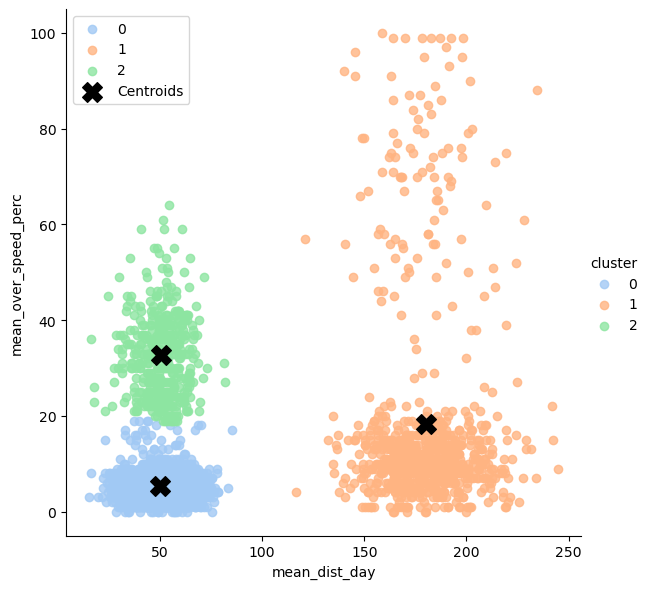

In [120]:
sns.lmplot(
    data=data,
    x='mean_dist_day',
    y='mean_over_speed_perc',
    hue='Cluster',
    palette=color_palette('pastel', n_colors=3),
    height=6,
    aspect=1,
    fit_reg=False
)

plt.scatter(
    centroids[:, 0],   # x values of centroids
    centroids[:, 1],   # y values of centroids
    s=200,             # size
    c='black',         # color
    marker='X',        # marker style
    label='Centroids'
)

plt.legend()
plt.show()